In [1]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.6 MB/s eta 0:00:00


In [2]:
!pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 2.5 MB/s eta 0:00:00


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV, KFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, QuantileTransformer, PowerTransformer, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error,classification_report, f1_score, accuracy_score, roc_curve, auc, precision_recall_curve
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.compose import ColumnTransformer
from sklearn.inspection import permutation_importance
from sklearn.manifold import TSNE
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical
import scipy.stats as stats
from catboost import CatBoostRegressor, Pool, CatBoostClassifier

In [4]:
pd.set_option('display.max_columns',None)

In [5]:
df = pd.read_csv('/content/df_train_2_FE.csv')

df_val = pd.read_csv('https://raw.githubusercontent.com/ichiP245/TP_Kaggle_Predictivo/refs/heads/main/Datasets/df_val_2_FE_sinOutliers.csv')

df.dropna(inplace=True)

df['key'] = df['key'].astype(str)
df['mode'] = df['mode'].astype(str)
df['grupo_anio'] = df['grupo_anio'].astype(str)
df['len_playlist_name'] = df['len_playlist_name'].astype(str)
df['tonality'] = df['tonality'].astype(str)

df['distance_mean_duration_min'] = (df['duration_min'] - df['duration_min'].mean())
df['distance_sq_mean_duration_min'] = (df['distance_mean_duration_min'])**2
df['log_duration_min'] = np.log(df['duration_min'])
df['z_duration_min'] = (df['duration_min'] - df['duration_min'].mean())/df['duration_min'].std()

df_val = df_val.drop(columns=['duration_min','duration_mins'])
df_val['loudness'] = df_val['new_loudness']
df_val['liveness'] = df_val['new_liveness']
df_val['duration_min'] = df_val['new_duration_mins']
df_val['distance_mean_duration_min'] = (df_val['duration_min'] - df['duration_min'].mean())
df_val['distance_sq_mean_duration_min'] = (df_val['distance_mean_duration_min'])**2
df_val['log_duration_min'] = np.log(df_val['duration_min'])
df_val['z_duration_min'] = (df_val['duration_min'] - df['duration_min'].mean())/df['duration_min'].std()

## Revisamos variables categoricas

In [ ]:
col = 'track_id'
print('columna',col)
print(f'Filas del df: {df.shape[0]}')
print(f'Valores unicos: {df[col].nunique()}')
val_count = df[col].value_counts()
x=5
print(f'Cantidad de valores con al menos {x} canciones: {val_count[val_count>x].shape[0]}')

columna track_id
Filas del df: 26261
Valores unicos: 22991
Cantidad de valores con al menos 5 canciones: 40


In [ ]:
col = 'track_name'
print(f'Filas del df: {df.shape[0]}')
print(f'Valores unicos: {df[col].nunique()}')
val_count = df[col].value_counts()
x=10
print(f'Cantidad de valores con al menos {x} canciones: {val_count[val_count>x].shape[0]}')

Filas del df: 26261
Valores unicos: 19269
Cantidad de valores con al menos 10 canciones: 23


In [ ]:
col = 'track_artist'
print(f'Filas del df: {df.shape[0]}')
print(f'Valores unicos: {df[col].nunique()}')
val_count = df[col].value_counts()
x=20
print(f'Cantidad de valores con al menos {x} canciones: {val_count[val_count>x].shape[0]}')

Filas del df: 26261
Valores unicos: 8786
Cantidad de valores con al menos 20 canciones: 159


In [ ]:
col = 'track_album_id'
print(f'Filas del df: {df.shape[0]}')
print(f'Valores unicos: {df[col].nunique()}')
val_count = df[col].value_counts()
x=5
print(f'Cantidad de valores con al menos {x} canciones: {val_count[val_count>x].shape[0]}')

Filas del df: 26261
Valores unicos: 17814
Cantidad de valores con al menos 5 canciones: 340


In [ ]:
col = 'track_album_name'
print(f'Filas del df: {df.shape[0]}')
print(f'Valores unicos: {df[col].nunique()}')
val_count = df[col].value_counts()
x=10
print(f'Cantidad de valores con al menos {x} canciones: {val_count[val_count>x].shape[0]}')

Filas del df: 26261
Valores unicos: 15961
Cantidad de valores con al menos 10 canciones: 88


Playlist_name y Playlist_id ni las miramos porque son muy diferentes a las que hay en validation

In [ ]:
interseccion_playlist_name = set(df['playlist_name'].values) & set(df_val['playlist_name'].values)
len(interseccion_playlist_name)

3

In [ ]:
cant = 0
for i in interseccion_playlist_name:
  cant+=df[df['playlist_name']==i].shape[0]

print(f'Cantidad total de canciones de train cuyo playlist_name esta en val: {cant}')

Cantidad total de canciones de train cuyo playlist_name esta en val: 97


In [ ]:
col = 'playlist_id'
print(f'Filas del df: {df.shape[0]}')
print(f'Valores unicos: {df[col].nunique()}')
val_count = df[col].value_counts()
x=30
print(f'Cantidad de valores con al menos {x} canciones: {val_count[val_count>x].shape[0]}')

Filas del df: 26261
Valores unicos: 390
Cantidad de valores con al menos 30 canciones: 339


In [ ]:
col = 'playlist_name'
print(f'Filas del df: {df.shape[0]}')
print(f'Valores unicos: {df[col].nunique()}')
val_count = df[col].value_counts()
x=10
print(f'Cantidad de valores con al menos {x} canciones: {val_count[val_count>x].shape[0]}')

Filas del df: 26261
Valores unicos: 368
Cantidad de valores con al menos 30 canciones: 321


## Limpieza pre-Modelo

FE de tiempo

In [6]:
df['tiene_mes_y_dia'] = (df['track_album_release_date'].apply(lambda x: x.count('-')) == 2).astype(int)

serie_tiempo = pd.to_datetime(df.loc[df['tiene_mes_y_dia'] == 1, 'track_album_release_date'])

df['mes'] = 13
df.loc[df['tiene_mes_y_dia'] == 1, 'mes'] = serie_tiempo.dt.month

df['dia'] = 32
df.loc[df['tiene_mes_y_dia'] == 1, 'dia'] = serie_tiempo.dt.day

df['tiene_mes_y_dia'] = df['tiene_mes_y_dia'].astype(str)
df['mes'] = df['mes'].astype(str)
df['dia'] = df['dia'].astype(str)

Lo hacemos con val set tambien

In [7]:
df_val['tiene_mes_y_dia'] = (df_val['track_album_release_date'].apply(lambda x: x.count('-')) == 2).astype(int)

serie_tiempo = pd.to_datetime(df_val.loc[df_val['tiene_mes_y_dia'] == 1, 'track_album_release_date'])

df_val['mes'] = 13
df_val.loc[df_val['tiene_mes_y_dia'] == 1, 'mes'] = serie_tiempo.dt.month

df_val['dia'] = 32
df_val.loc[df_val['tiene_mes_y_dia'] == 1, 'dia'] = serie_tiempo.dt.day

df_val['tiene_mes_y_dia'] = df_val['tiene_mes_y_dia'].astype(str)
df_val['mes'] = df_val['mes'].astype(str)
df_val['dia'] = df_val['dia'].astype(str)

Esta de abajo no la ejecuto cuando hago el CatBoost Classifier de 0s

In [ ]:
df.drop(columns=['Unnamed: 0', 'track_id', 'track_name', 'track_artist', 'track_album_id', 'track_album_name',
       'track_album_release_date', 'playlist_name', 'playlist_id', 'track_popularity_bins', 'es0'], inplace=True)

## Clasificacion 0s: Catboost

In [10]:
X = df.drop(columns=['es0','track_popularity', 'track_popularity_bins', 'anio', 'track_album_release_date',
                     'playlist_name', 'playlist_id', 'playlist_genre', 'playlist_subgenre', 'Unnamed: 0'])
y = df['es0']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

cat_features=X.select_dtypes(include='object').columns.to_list()
train_pool = Pool(X_train, y_train, cat_features=cat_features)
val_pool = Pool(X_val, y_val, cat_features=cat_features)

In [14]:
catboost_c = CatBoostClassifier(
    iterations=1500,
    learning_rate=0.015,
    loss_function='Logloss',
    eval_metric='Recall',
    random_seed=42,
    verbose=100,
    depth=5,
    early_stopping_rounds=250)

# ── ENTRENAMIENTO ──────────────────────────────────────────────
catboost_c.fit(train_pool, eval_set=val_pool)

print('\nTRAIN')
y_pred = catboost_c.predict(X_train)
print(classification_report(y_train, y_pred))

print('VAL')
y_pred = catboost_c.predict(X_val)
print(classification_report(y_val, y_pred))

print('TEST')
y_pred = catboost_c.predict(X_test)
print(classification_report(y_test, y_pred))

0:	learn: 0.0000000	test: 0.0000000	best: 0.0000000 (0)	total: 145ms	remaining: 3m 37s
100:	learn: 0.2234130	test: 0.3564356	best: 0.3564356 (100)	total: 11.1s	remaining: 2m 33s
200:	learn: 0.2308326	test: 0.3597360	best: 0.3597360 (197)	total: 17.4s	remaining: 1m 52s
300:	learn: 0.2366035	test: 0.3663366	best: 0.3663366 (286)	total: 26.1s	remaining: 1m 43s
400:	learn: 0.2456719	test: 0.3663366	best: 0.3663366 (286)	total: 33.8s	remaining: 1m 32s
500:	learn: 0.2497939	test: 0.3663366	best: 0.3663366 (286)	total: 41.9s	remaining: 1m 23s
600:	learn: 0.2563891	test: 0.3696370	best: 0.3729373 (590)	total: 50.5s	remaining: 1m 15s
700:	learn: 0.2671063	test: 0.3729373	best: 0.3729373 (590)	total: 57.7s	remaining: 1m 5s
800:	learn: 0.2687552	test: 0.3729373	best: 0.3729373 (590)	total: 1m 6s	remaining: 57.9s
Stopped by overfitting detector  (250 iterations wait)

bestTest = 0.3729372937
bestIteration = 590

Shrink model to first 591 iterations.

TRAIN
              precision    recall  f1-sco

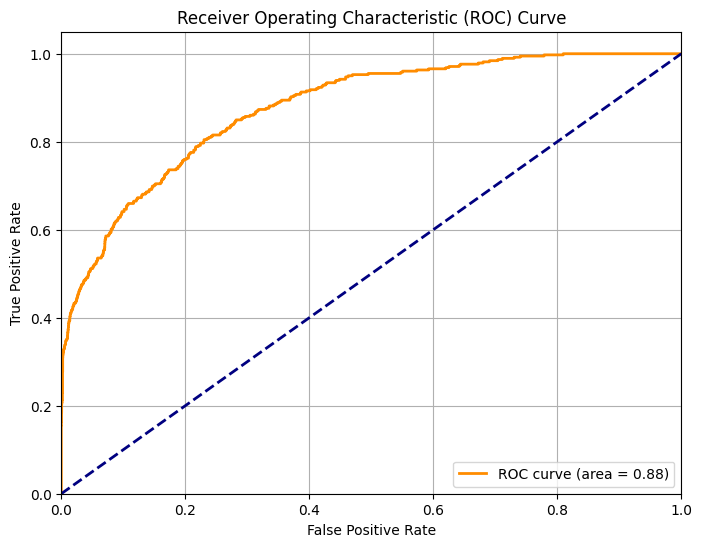

In [18]:
# Get predicted probabilities for the positive class (class 1)
y_pred_proba = catboost_c.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Calculate AUC
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

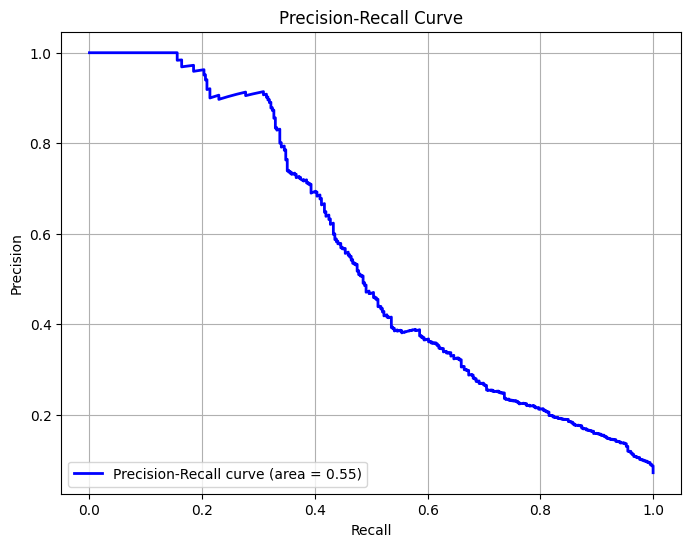

In [19]:
# Get predicted probabilities for the positive class (class 1)
y_pred_proba = catboost_c.predict_proba(X_test)[:, 1]

# Calculate Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

# Calculate Area Under the Curve (AUC) for Precision-Recall
pr_auc = auc(recall, precision)

# Plot Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', lw=2, label=f'Precision-Recall curve (area = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

In [20]:
# --- Optimal Threshold for ROC Curve (maximizing TPR - FPR) ---
fpr, tpr, thresholds_roc = roc_curve(y_test, y_pred_proba)

# Find the optimal threshold for ROC curve (Youden's J statistic)
optimal_idx_roc = np.argmax(tpr - fpr)
optimal_threshold_roc = thresholds_roc[optimal_idx_roc]
print(f"Optimal Threshold (ROC - Max (TPR - FPR)): {optimal_threshold_roc:.4f}")

# --- Optimal Threshold for Precision-Recall Curve (maximizing F1-score) ---
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_pred_proba)

# Calculate F1-scores for each threshold
f_scores = 2 * (precision * recall) / (precision + recall)

# Handle potential NaN values where precision + recall = 0
f_scores[np.isnan(f_scores)] = 0

# Find the optimal threshold for PR curve (maximizing F1-score)
optimal_idx_pr = np.argmax(f_scores)
optimal_threshold_pr = thresholds_pr[optimal_idx_pr]

print(f"Optimal Threshold (Precision-Recall - Max F1-score): {optimal_threshold_pr:.4f}")

Optimal Threshold (ROC - Max (TPR - FPR)): 0.0771
Optimal Threshold (Precision-Recall - Max F1-score): 0.2599


Este es el classification_report cuando el threshold es optimo para la curva recall-precision (threshold=0.2599)

In [24]:
y_pred_optimal_pr = (y_pred_proba > optimal_threshold_pr).astype(int)
print("Classification Report with Optimal PR Threshold:")
print(classification_report(y_test, y_pred_optimal_pr))

Classification Report with Optimal PR Threshold:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      4874
           1       0.67      0.41      0.51       379

    accuracy                           0.94      5253
   macro avg       0.81      0.70      0.74      5253
weighted avg       0.93      0.94      0.94      5253



No estoy dispuesto a ese threshold porque me dan 148 valores en 0

In [21]:
pred_binary_kaggle_set = catboost_c.predict_proba(df_val[X_train.columns])[:,1]
modelo_o_no = (pred_binary_kaggle_set > optimal_threshold_pr).astype(int)

In [23]:
modelo_o_no.sum()

np.int64(148)

Me parece que me quedo con el threshold de 0,5, que en test me aseguro un 90% de precision

In [26]:
catboost_c.predict(df_val[X_train.columns.to_list()]).sum()

np.int64(28)

Hago que prediga 0 si el modelo dijo 0 y sino que prediga la averaged optima

In [50]:
avg_sub_mejor = pd.read_csv('https://raw.githubusercontent.com/ichiP245/TP_Kaggle_Predictivo/refs/heads/main/Submissions/averaged_submission.csv')

print('Cantidad de 0s antes', avg_sub_mejor[avg_sub_mejor['track_popularity']==0].count()['track_popularity'])

# Re-populating prediccion to ensure it reflects the expected predictions
prediccion = catboost_c.predict(df_val[X_train.columns.to_list()])

avg_sub_mejor['resul_classif_0'] = prediccion
avg_sub_mejor['track_popularity'] = avg_sub_mejor.apply(lambda row: 0 if row['resul_classif_0']==1 else row['track_popularity'], axis=1)

print('Cantidad de 0s despues', avg_sub_mejor[avg_sub_mejor['track_popularity']==0].count()['track_popularity'])

avg_sub_mejor[['ID','track_popularity']].to_csv('avg_sub_imputados_0s_otra_vez.csv', index=False)

Cantidad de 0s antes 0
Cantidad de 0s despues 28


## Modelo inicial

In [ ]:
#saco playlist_subgenre para no overfittear
X = df.drop(columns=['mode','key','track_popularity','duration_ms','anio','playlist_subgenre'])
y = df['track_popularity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

cat_features = X.select_dtypes(include='object').columns.to_list()
train_pool = Pool(X_train, y_train, cat_features=cat_features)
val_pool = Pool(X_val, y_val, cat_features=cat_features)

Modelo inicial: Diferencia de 25 puntos porcentuales entre R^2 de train y test: signo de overfitting

In [ ]:
catboost_r0 =  CatBoostRegressor(iterations=1000,learning_rate=0.025,loss_function='RMSE',eval_metric='R2',
                                early_stopping_rounds=50,random_seed=42,verbose=100
                                 )

catboost_r0.fit(train_pool, eval_set=val_pool)

print('TRAIN')
y_pred = catboost_r0.predict(X_train)
print(f"R²:   {r2_score(y_train, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_pred)):.4f}")

print('VAL')
y_pred = catboost_r0.predict(X_val)
print(f"R²:   {r2_score(y_val, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_val, y_pred)):.4f}")

print('TEST')
y_pred = catboost_r0.predict(X_test)
print(f"R²:   {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

0:	learn: 0.0048394	test: 0.0007833	best: 0.0007833 (0)	total: 114ms	remaining: 1m 54s
100:	learn: 0.1957169	test: 0.1796770	best: 0.1796770 (100)	total: 5.07s	remaining: 45.1s
200:	learn: 0.2385956	test: 0.2151521	best: 0.2151521 (200)	total: 10.9s	remaining: 43.3s
300:	learn: 0.2640088	test: 0.2300127	best: 0.2300127 (300)	total: 16.7s	remaining: 38.8s
400:	learn: 0.2849727	test: 0.2435090	best: 0.2435090 (400)	total: 21.7s	remaining: 32.4s
500:	learn: 0.3071530	test: 0.2573088	best: 0.2573088 (500)	total: 27.7s	remaining: 27.6s
600:	learn: 0.3297353	test: 0.2661977	best: 0.2661977 (600)	total: 32.5s	remaining: 21.5s
700:	learn: 0.3494370	test: 0.2705643	best: 0.2705643 (700)	total: 38.7s	remaining: 16.5s
800:	learn: 0.3666622	test: 0.2769619	best: 0.2769619 (800)	total: 43.7s	remaining: 10.9s
900:	learn: 0.3808907	test: 0.2822345	best: 0.2822670 (898)	total: 49.6s	remaining: 5.45s
999:	learn: 0.3938513	test: 0.2874182	best: 0.2874216 (998)	total: 55.4s	remaining: 0us

bestTest = 0.2

## Optimizar modelo inicial

### Optimización Random Search

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

# Base CatBoostRegressor model with early stopping
cb_model = CatBoostRegressor(
    loss_function='RMSE',
    eval_metric='R2',
    random_seed=42,
    verbose=0, # Suppress verbose output during search
    early_stopping_rounds=50,
    iterations=2000 # Set a sufficiently large number, early stopping will prevent overfitting
)

# Define parameter distribution for RandomizedSearchCV
param_dist = {
    'learning_rate': uniform(0.01, 0.1),  # From 0.01 to 0.11
    'depth': randint(4, 11),  # From 4 to 10
    'l2_leaf_reg': uniform(1, 10), # From 1 to 11
    'rsm': uniform(0.7, 0.3), # Feature subsampling ratio (corresponds to colsample_bylevel in other GBMs)
    'border_count': randint(32, 256), # Number of splits for numerical features
}

# Number of iterations for RandomizedSearchCV and cross-validation folds
n_iter_search = 10 # Number of parameter settings that are sampled.
cv_folds = 3 # Number of cross-validation splits

random_search = RandomizedSearchCV(
    estimator=cb_model,
    param_distributions=param_dist,
    n_iter=n_iter_search,
    cv=cv_folds,
    scoring='r2',
    random_state=42,
    n_jobs=-1, # Use all available cores
    verbose=1 # Higher verbosity for more details
)

print("Starting RandomizedSearchCV...")
# Fit RandomizedSearchCV, passing cat_features to the CatBoost estimator
random_search.fit(X_train, y_train, cat_features=cat_features)
print("RandomizedSearchCV finished.")

print("\nBest parameters found: ", random_search.best_params_)
print("Best R2 score found: {:.4f}".format(random_search.best_score_))

# Evaluate the best model
best_catboost_model = random_search.best_estimator_

print('\nTRAIN - Optimized Model')
y_pred_train = best_catboost_model.predict(X_train)
print(f"R²:   {r2_score(y_train, y_pred_train):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train)):.4f}")

print('VAL - Optimized Model')
y_pred_val = best_catboost_model.predict(X_val)
print(f"R²:   {r2_score(y_val, y_pred_val):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_val, y_pred_val)):.4f}")

print('TEST - Optimized Model')
y_pred_test = best_catboost_model.predict(X_test)
print(f"R²:   {r2_score(y_test, y_pred_test):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.4f}")

Starting RandomizedSearchCV...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
RandomizedSearchCV finished.

Best parameters found:  {'border_count': 82, 'depth': 10, 'l2_leaf_reg': np.float64(2.705241236872915), 'learning_rate': np.float64(0.01650515929852795), 'rsm': np.float64(0.9846656611759999)}
Best R2 score found: 0.2875

TRAIN - Optimized Model
R²:   0.7503
RMSE: 12.5111
VAL - Optimized Model
R²:   0.3205
RMSE: 20.3293
TEST - Optimized Model
R²:   0.3166
RMSE: 20.7151


Best parameters found:  {'border_count': 82, 'depth': 10, 'l2_leaf_reg': np.float64(2.705241236872915), 'learning_rate': np.float64(0.01650515929852795), 'rsm': np.float64(0.9846656611759999)}

Best R2 score found: 0.2875

TRAIN - Optimized Model
R²:   0.7503
RMSE: 12.5111

VAL - Optimized Model
R²:   0.3205
RMSE: 20.3293

TEST - Optimized Model
R²:   0.3166
RMSE: 20.7151

### Optimización BayesCV

Probar learning rate mas bajo y otras combinaciones mas cercanas a los parametros ideales

In [ ]:
#saco playlist_subgenre Y playlist_genre para no overfittear
X = df.drop(columns=['mode','key','track_popularity','duration_ms','anio','playlist_genre','playlist_subgenre'])
y = df['track_popularity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

cat_features = X.select_dtypes(include='object').columns.to_list()
train_pool = Pool(X_train, y_train, cat_features=cat_features)
val_pool = Pool(X_val, y_val, cat_features=cat_features)

In [ ]:
# Base CatBoostRegressor model with early stopping
cb_model_bayes = CatBoostRegressor(
    loss_function='RMSE',
    eval_metric='R2',
    random_seed=42,
    verbose=0, # Suppress verbose output during search
    early_stopping_rounds=50,
    # iterations will be tuned by BayesSearchCV,
    thread_count=-1
)

# Define the search space for BayesSearchCV
# Using Real for continuous parameters, Integer for discrete ones.
# The 'prior' argument helps guide the search (e.g., 'log-uniform' for learning rate).
param_space = {
    'learning_rate': Real(0.001, 0.1, prior='log-uniform'), # A broader range for learning rate
    'depth': Integer(4, 10), # Consistent with previous search
    'l2_leaf_reg': Real(1e-2, 10, prior='log-uniform'), # L2 regularization
    'iterations': Integer(100, 2000), # Now optimizing the number of iterations as well
    'bagging_temperature': Real(0.0, 1.0), # New parameter: Bagging temperature
    'random_strength': Real(0.0, 1.0) # New parameter: Random strength
}

# Number of iterations for Bayesian Optimization
n_iter_bayes = 15 # Increased iterations for a more thorough search

bayes_search = BayesSearchCV(
    estimator=cb_model_bayes,
    search_spaces=param_space,
    n_iter=n_iter_bayes,
    cv=3, # Using 3-fold cross-validation
    scoring='r2',
    random_state=42,
    n_jobs=1, # Does NOT use all available cores
    verbose=1
)

print("Starting Bayesian Optimization with BayesSearchCV...")
bayes_search.fit(X_train, y_train, cat_features=cat_features)
print("Bayesian Optimization finished.")

print("\nBest parameters found with Bayesian Optimization: ", bayes_search.best_params_)
print("Best R2 score found with Bayesian Optimization: {:.4f}".format(bayes_search.best_score_))

# Evaluate the best model from Bayesian Optimization
best_catboost_model_bayes = bayes_search.best_estimator_

print('\nTRAIN - Optimized Model (Bayes)')
y_pred_train_bayes = best_catboost_model_bayes.predict(X_train)
print(f"R²:   {r2_score(y_train, y_pred_train_bayes):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train_bayes)):.4f}")

print('VAL - Optimized Model (Bayes)')
y_pred_val_bayes = best_catboost_model_bayes.predict(X_val)
print(f"R²:   {r2_score(y_val, y_pred_val_bayes):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_val, y_pred_val_bayes)):.4f}")

print('TEST - Optimized Model (Bayes)')
y_pred_test_bayes = best_catboost_model_bayes.predict(X_test)
print(f"R²:   {r2_score(y_test, y_pred_test_bayes):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test_bayes)):.4f}")

Starting Bayesian Optimization with BayesSearchCV...
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Bayesian Optimization finished.

Best parameters found with Ba

Best parameters found with Bayesian Optimization:

OrderedDict({'bagging_temperature': 0.41010395885331385, 'depth': 8, 'iterations': 1872, 'l2_leaf_reg': 0.08859287192002238, 'learning_rate': 0.021892527128216443, 'random_strength': 0.4141186324855385})


#### Combinacion de modelos

In [ ]:
# Parametros de optimizacion con Random Search CV
params1 = {'border_count': 82, 'depth': 10, 'l2_leaf_reg': np.float64(2.705241236872915),
           'learning_rate': np.float64(0.01650515929852795), 'rsm': np.float64(0.9846656611759999)}
# Parametros de optimizacion con Bayes CV
params2 = {'bagging_temperature': 0.41010395885331385, 'depth': 8, 'iterations': 1872, 'l2_leaf_reg': 0.08859287192002238,
           'learning_rate': 0.021892527128216443, 'random_strength': 0.4141186324855385}

catboost_params1 = CatBoostRegressor(**params1, loss_function='RMSE', eval_metric='R2', random_seed=42, verbose=0)
catboost_params2 = CatBoostRegressor(**params2, loss_function='RMSE', eval_metric='R2', random_seed=42, verbose=0)

catboost_params1.fit(train_pool, eval_set=val_pool)
catboost_params2.fit(train_pool, eval_set=val_pool)

y_pred_params1 = catboost_params1.predict(X_test)
y_pred_params2 = catboost_params2.predict(X_test)
y_pred_ensemble = (y_pred_params1 + y_pred_params2) / 2

In [ ]:
print('TEST - RandomSearchCV')
print(f"R²:   {r2_score(y_test, y_pred_params1):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_params1)):.4f}")
print('TEST - BayesCV')
print(f"R²:   {r2_score(y_test, y_pred_params2):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_params2)):.4f}")
print('TEST - Ensemble')
print(f"R²:   {r2_score(y_test, y_pred_ensemble):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_ensemble)):.4f}")

TEST - RandomSearchCV
R²:   0.2697
RMSE: 21.4146
TEST - BayesCV
R²:   0.2879
RMSE: 21.1455
TEST - Ensemble
R²:   0.2835
RMSE: 21.2110


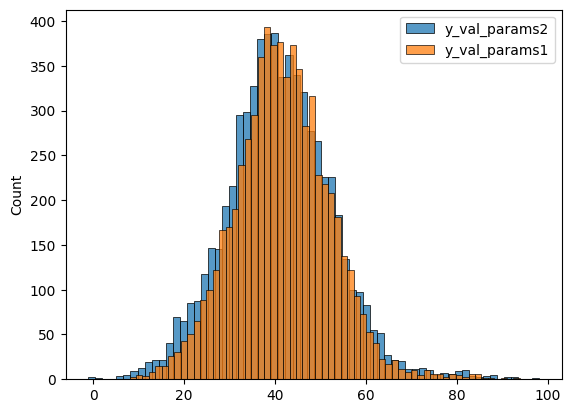

In [ ]:
y_val_params1 = catboost_params1.predict(df_val[X_train.columns])
y_val_params2 = catboost_params2.predict(df_val[X_train.columns])

sns.histplot(y_val_params2, label='y_val_params2')
sns.histplot(y_val_params1, label='y_val_params1')
plt.legend()
plt.show()

### Optimización Grid Search

In [ ]:
from sklearn.model_selection import GridSearchCV

# Base CatBoostRegressor model with early stopping
cb_model_grid = CatBoostRegressor(
    loss_function='RMSE',
    eval_metric='R2',
    random_seed=42,
    verbose=0, # Suppress verbose output during search
    early_stopping_rounds=50,
    iterations=2000, # Set a sufficiently large number, early stopping will prevent overfitting
    thread_count=-1,
    depth=6
    # cat_features is removed from here to prevent cloning issues with GridSearchCV
)

# Define the parameter grid for GridSearchCV
param_grid = {
    'learning_rate': [0.019, 0.035], # Explore lower learning rates
    'l2_leaf_reg': [1, 2.5] # Explore higher regularization values
}

# Number of cross-validation folds
cv_folds_grid = 3

grid_search = GridSearchCV(
    estimator=cb_model_grid,
    param_grid=param_grid,
    cv=cv_folds_grid,
    scoring='r2',
    n_jobs=-1, # Use all available cores
    verbose=1
)

print("Starting GridSearchCV...")
# Fit GridSearchCV with X_train, y_train and pass eval_set as (X_val, y_val) AND cat_features directly
grid_search.fit(X_train, y_train, eval_set=(X_val, y_val), cat_features=cat_features)
print("GridSearchCV finished.")

print("\nBest parameters found with Grid Search: ", grid_search.best_params_)
print("Best R2 score found with Grid Search: {:.4f}".format(grid_search.best_score_))

# Evaluate the best model from Grid Search
best_catboost_model_grid = grid_search.best_estimator_

print('\nTRAIN - Optimized Model (Grid Search)')
y_pred_train_grid = best_catboost_model_grid.predict(X_train)
print(f"R²:   {r2_score(y_train, y_pred_train_grid):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train_grid)):.4f}")

print('VAL - Optimized Model (Grid Search)')
y_pred_val_grid = best_catboost_model_grid.predict(X_val)
print(f"R²:   {r2_score(y_val, y_pred_val_grid):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_val, y_pred_val_grid)):.4f}")

print('TEST - Optimized Model (Grid Search)')
y_pred_test_grid = best_catboost_model_grid.predict(X_test)
print(f"R²:   {r2_score(y_test, y_pred_test_grid):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test_grid)):.4f}")

Starting GridSearchCV...
Fitting 3 folds for each of 4 candidates, totalling 12 fits
GridSearchCV finished.

Best parameters found with Grid Search:  {'l2_leaf_reg': 1, 'learning_rate': 0.019}
Best R2 score found with Grid Search: 0.2380

TRAIN - Optimized Model (Grid Search)
R²:   0.5586
RMSE: 16.6330
VAL - Optimized Model (Grid Search)
R²:   0.2653
RMSE: 21.1378
TEST - Optimized Model (Grid Search)
R²:   0.2670
RMSE: 21.4531


{'l2_leaf_reg': 1, 'learning_rate': 0.019}

Ensamble de los 3 optimizadores

In [ ]:
y_pred_grid_search = best_catboost_model_grid.predict(X_test)
ensembleX3 = (y_pred_params1 + y_pred_params2 + y_pred_grid_search) / 3

print('TEST - Ensemble')
print(f"R²:   {r2_score(y_test, ensembleX3):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, ensembleX3)):.4f}")

TEST - Ensemble
R²:   0.2800
RMSE: 21.2622


Prediccion set Kaggle

In [ ]:
y_val_grid_search = best_catboost_model_grid.predict(df_val[X_train.columns])

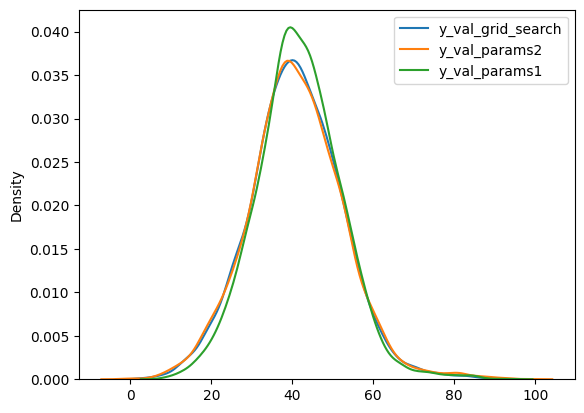

In [ ]:
sns.kdeplot(y_val_grid_search, label='y_val_grid_search')
sns.kdeplot(y_val_params2, label='y_val_params2')
sns.kdeplot(y_val_params1, label='y_val_params1')
plt.legend()
plt.show()

## AdaBoost

Venimos con el X_train de los modelos de arriba

In [ ]:
X_train_bis = X_train.drop(columns=['mes', 'dia','most_extreme_feature'])
X_val_bis = X_val.drop(columns=['mes', 'dia','most_extreme_feature'])
X_test_bis = X_test.drop(columns=['mes', 'dia','most_extreme_feature'])

# Define numerical and categorical features
numerical_features = X_train_bis.select_dtypes(include=np.number).columns
categorical_features = X_train_bis.select_dtypes(include='object').columns

# Create a preprocessor to handle numerical and categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Define the base estimator for AdaBoost
# A shallow decision tree (e.g., max_depth=5) is often a good choice for AdaBoost
base_estimator = DecisionTreeRegressor(max_depth=5, random_state=42)

# Create the AdaBoostRegressor model within a pipeline
adaboost_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', AdaBoostRegressor(
        estimator=base_estimator, # Changed 'base_estimator' to 'estimator'
        n_estimators=100, # Number of boosting stages
        learning_rate=0.15, # Weight applied to each regressor at each boosting iteration
        random_state=42
    ))
])

print("Starting AdaBoost Regressor training...")
adaboost_model.fit(X_train_bis, y_train)
print("AdaBoost Regressor training finished.")

print('\nTRAIN - AdaBoost Regressor')
y_pred_train_adaboost = adaboost_model.predict(X_train_bis)
print(f"R²:   {r2_score(y_train, y_pred_train_adaboost):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train_adaboost)):.4f}")

print('VAL - AdaBoost Regressor')
y_pred_val_adaboost = adaboost_model.predict(X_val)
print(f"R²:   {r2_score(y_val, y_pred_val_adaboost):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_val, y_pred_val_adaboost)):.4f}")

print('TEST - AdaBoost Regressor')
y_pred_test_adaboost = adaboost_model.predict(X_test)
print(f"R²:   {r2_score(y_test, y_pred_test_adaboost):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test_adaboost)):.4f}")


TRAIN - AdaBoost Regressor
R²:   0.1523
RMSE: 23.0509
VAL - AdaBoost Regressor
R²:   0.1033
RMSE: 23.3521
TEST - AdaBoost Regressor
R²:   0.1140
RMSE: 23.5873


Prediccion Kaggle set

In [ ]:
df_val_for_prediction = df_val[X_train_bis.columns].copy()

# Explicitly convert all identified categorical features to string type
# This handles potential mixed types and converts any np.nan to the string 'nan'
for col in categorical_features:
    if col in df_val_for_prediction.columns:
        df_val_for_prediction[col] = df_val_for_prediction[col].astype(str)

# Now, replace the string 'nan' (which came from actual np.nan values) with 'missing_category'
for col in categorical_features:
    if col in df_val_for_prediction.columns:
        df_val_for_prediction[col] = df_val_for_prediction[col].replace('nan', 'missing_category')

y_val_adaboost = adaboost_model.predict(df_val_for_prediction)

<Axes: ylabel='Density'>

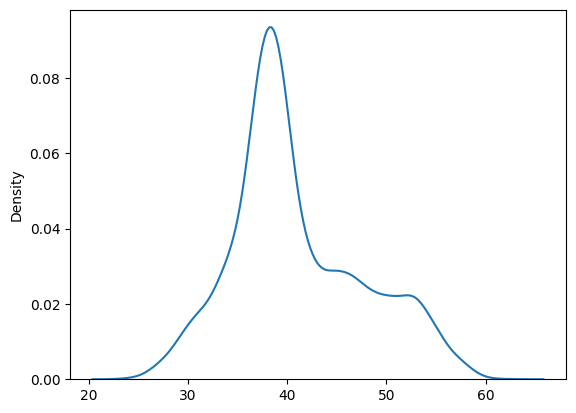

In [ ]:
sns.kdeplot(y_val_adaboost, label='y_val_adaboost')

## TabNet nuevo

In [ ]:
!pip install pytorch-tabnet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.5 MB/s eta 0:00:00


In [ ]:
import torch
from pytorch_tabnet.tab_model import TabNetRegressor

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.select_dtypes(include='number'))
X_val_scaled = scaler.transform(X_val.select_dtypes(include='number'))
X_test_scaled  = scaler.transform(X_test.select_dtypes(include='number'))

# ── 2. MODELO ──────────────────────────────────────────────────
reg = TabNetRegressor(
    n_d=24,
    n_a=24,
    n_steps=3,                 # bajado de 5 → menos overfit con pocos datos
    gamma=1.5,
    lambda_sparse=1e-2,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=0.01),
    mask_type='sparsemax',
    seed=42,
    verbose=10                 # imprime métricas cada 10 épocas
)

# ── 3. ENTRENAMIENTO ───────────────────────────────────────────
reg.fit(
    X_train_scaled, y_train.values.reshape(-1, 1),
    eval_set=[(X_val_scaled, y_val.values.reshape(-1, 1))],
    eval_name=['val'],
    eval_metric=['rmse'],
    max_epochs=250,
    patience=20,
    batch_size=512,            # bajado de 1024 → más actualizaciones por época
    virtual_batch_size=128,
    num_workers=0,
    drop_last=False
)

# ── 4. EVALUACIÓN ──────────────────────────────────────────────
y_pred = reg.predict(X_train_scaled)
print("=== MÉTRICAS EN TRAIN SET ===")
print(f"R²:   {r2_score(y_train, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_pred)):.4f}")

y_pred = reg.predict(X_val_scaled)
print("=== MÉTRICAS EN VAL SET ===")
print(f"R²:   {r2_score(y_val, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_val, y_pred)):.4f}")

y_pred = reg.predict(X_test_scaled)
print("=== MÉTRICAS EN TEST SET ===")
print(f"R²:   {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 1991.31297| val_rmse: 36.86665|  0:00:01s
epoch 10 | loss: 576.90975| val_rmse: 23.69503|  0:00:22s
epoch 20 | loss: 540.57689| val_rmse: 23.10789|  0:00:43s
epoch 30 | loss: 522.23934| val_rmse: 23.08164|  0:01:03s
epoch 40 | loss: 515.21602| val_rmse: 23.03419|  0:01:23s

Early stopping occurred at epoch 46 with best_epoch = 26 and best_val_rmse = 22.93119


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


=== MÉTRICAS EN TRAIN SET ===
R²:   0.1727
RMSE: 22.7722
=== MÉTRICAS EN VAL SET ===
R²:   0.1354
RMSE: 22.9312
=== MÉTRICAS EN TEST SET ===
R²:   0.1223
RMSE: 23.4756


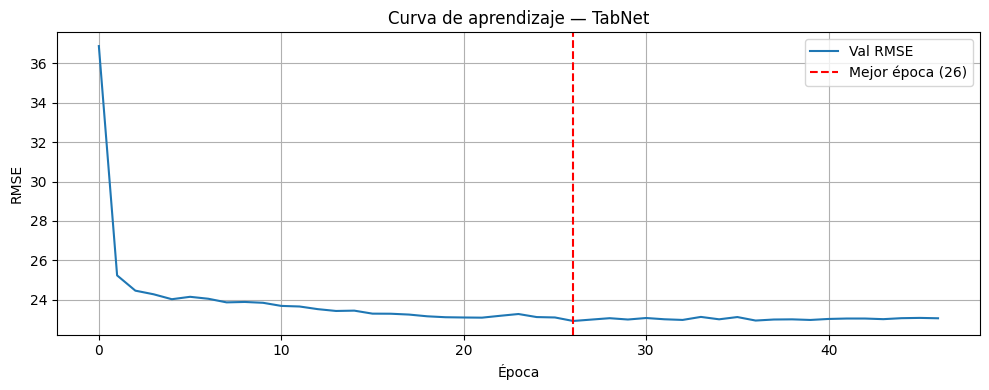

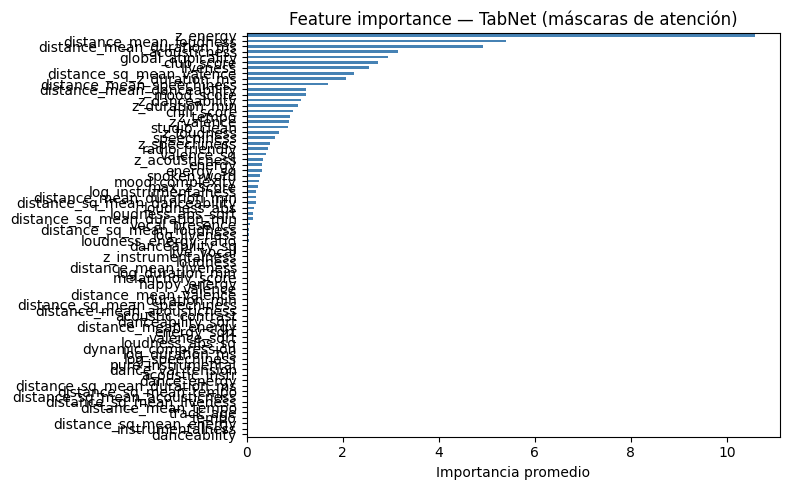

In [ ]:
# ── 5. CURVA DE APRENDIZAJE ────────────────────────────────────
plt.figure(figsize=(10, 4))
plt.plot(reg.history['val_rmse'], label='Val RMSE')
plt.axvline(np.argmin(reg.history['val_rmse']),
            color='red', linestyle='--',
            label=f"Mejor época ({np.argmin(reg.history['val_rmse'])})")
plt.xlabel('Época')
plt.ylabel('RMSE')
plt.title('Curva de aprendizaje — TabNet')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ── 6. MÁSCARAS DE ATENCIÓN (interpretabilidad) ────────────────
# Qué features usó el modelo en cada predicción
masks = reg.explain(X_test_scaled)
feature_importance = masks[0].mean(axis=0)

fi_series = pd.Series(feature_importance, index=X_train.select_dtypes(include='number').columns)\
              .sort_values(ascending=True)

plt.figure(figsize=(8, 5))
fi_series.plot(kind='barh', color='steelblue')
plt.title('Feature importance — TabNet (máscaras de atención)')
plt.xlabel('Importancia promedio')
plt.tight_layout()
plt.show()

Prediccion Kaggle set

In [ ]:
y_val_tabnet = reg.predict(scaler.transform(df_val[X_train.select_dtypes(include='number').columns.to_list()]))

Segundo modelo con menos variables

In [ ]:
pd.DataFrame(fi_series.sort_values(ascending=False)).T

,z_energy,distance_mean_loudness,distance_mean_duration_ms,acousticness,global_atipicality,club_score,liveness,distance_sq_mean_valence,z_duration_ms,distance_mean_speechiness,distance_mean_danceability,mood_score,z_danceability,z_duration_min,chill_score,z_tempo,z_valence,studio_clean,z_loudness,speechiness,z_speechiness,radio_friendly,valence_sq,z_acousticness,energy,energy_sq,spoken_word,mood_complexity,max_z_score,log_instrumentalness,distance_mean_duration_min,distance_sq_mean_danceability,loudness_abs,loudness_abs_sqrt,distance_sq_mean_duration_min,vocal_presence,distance_sq_mean_loudness,log_liveness,loudness_energy_ratio,danceability_sq,live_vocal,z_instrumentalness,loudness,distance_mean_liveness,log_duration_min,melancholy_score,happy_energy,valence,distance_mean_valence,duration_min,distance_sq_mean_speechiness,distance_mean_acousticness,acoustic_contrast,danceability_sqrt,distance_mean_energy,distance_sq_mean_energy,instrumentalness,danceability,tempo,dance_energy,distance_sq_mean_duration_ms,distance_sq_mean_tempo,distance_sq_mean_acousticness,distance_sq_mean_liveness,distance_mean_tempo,track_age,valence_sqrt,energy_sqrt,loudness_abs_sq,dynamic_compression,log_duration_ms,log_speechiness,pure_instrumental,dance_val_tension,acoustic_instr
0,10.576353,5.404536,4.913942,3.157266,2.941769,2.733757,2.536816,2.228069,2.069309,1.700969,1.240336,1.23218,1.130503,1.059768,0.959625,0.895476,0.886819,0.866691,0.673052,0.584746,0.486285,0.450082,0.392133,0.346803,0.324113,0.315361,0.277626,0.260792,0.240401,0.200864,0.192315,0.188371,0.150013,0.139319,0.124151,0.058437,0.056781,0.055471,0.051243,0.017746,0.015048,0.007923,0.007292,0.004517,0.00407,0.003812,0.002649,0.000643,0.000626,0.000223,0.000221,0.000075,0.000062,0.000042,0.000007,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
fi_series[fi_series>0.01].index.to_list()

['live_vocal',
 'danceability_sq',
 'loudness_energy_ratio',
 'log_liveness',
 'distance_sq_mean_loudness',
 'vocal_presence',
 'distance_sq_mean_duration_min',
 'loudness_abs_sqrt',
 'loudness_abs',
 'distance_sq_mean_danceability',
 'distance_mean_duration_min',
 'log_instrumentalness',
 'max_z_score',
 'mood_complexity',
 'spoken_word',
 'energy_sq',
 'energy',
 'z_acousticness',
 'valence_sq',
 'radio_friendly',
 'z_speechiness',
 'speechiness',
 'z_loudness',
 'studio_clean',
 'z_valence',
 'z_tempo',
 'chill_score',
 'z_duration_min',
 'z_danceability',
 'mood_score',
 'distance_mean_danceability',
 'distance_mean_speechiness',
 'z_duration_ms',
 'distance_sq_mean_valence',
 'liveness',
 'club_score',
 'global_atipicality',
 'acousticness',
 'distance_mean_duration_ms',
 'distance_mean_loudness',
 'z_energy']

In [ ]:
import torch
from pytorch_tabnet.tab_model import TabNetRegressor

cols = fi_series[fi_series>0.01].index.to_list()

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[cols])
X_val_scaled = scaler.transform(X_val[cols])
X_test_scaled  = scaler.transform(X_test[cols])

# ── 2. MODELO ──────────────────────────────────────────────────
reg = TabNetRegressor(
    n_d=24,
    n_a=24,
    n_steps=3,                 # bajado de 5 → menos overfit con pocos datos
    gamma=1.5,
    lambda_sparse=1e-2,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=0.01),
    mask_type='sparsemax',
    seed=42,
    verbose=10                 # imprime métricas cada 10 épocas
)

# ── 3. ENTRENAMIENTO ───────────────────────────────────────────
reg.fit(
    X_train_scaled, y_train.values.reshape(-1, 1),
    eval_set=[(X_val_scaled, y_val.values.reshape(-1, 1))],
    eval_name=['val'],
    eval_metric=['rmse'],
    max_epochs=250,
    patience=20,
    batch_size=512,            # bajado de 1024 → más actualizaciones por época
    virtual_batch_size=128,
    num_workers=0,
    drop_last=False
)

# ── 4. EVALUACIÓN ──────────────────────────────────────────────
y_pred = reg.predict(X_train_scaled)
print("=== MÉTRICAS EN TRAIN SET ===")
print(f"R²:   {r2_score(y_train, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_pred)):.4f}")

y_pred = reg.predict(X_val_scaled)
print("=== MÉTRICAS EN VAL SET ===")
print(f"R²:   {r2_score(y_val, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_val, y_pred)):.4f}")

y_pred = reg.predict(X_test_scaled)
print("=== MÉTRICAS EN TEST SET ===")
print(f"R²:   {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 2063.67746| val_rmse: 37.15486|  0:00:01s
epoch 10 | loss: 591.4741| val_rmse: 24.07171|  0:00:18s
epoch 20 | loss: 578.69092| val_rmse: 23.85886|  0:00:35s
epoch 30 | loss: 571.80487| val_rmse: 23.92234|  0:00:53s
epoch 40 | loss: 568.23903| val_rmse: 23.69297|  0:01:10s
epoch 50 | loss: 556.68605| val_rmse: 23.70657|  0:01:27s
epoch 60 | loss: 549.81323| val_rmse: 23.84201|  0:01:45s

Early stopping occurred at epoch 66 with best_epoch = 46 and best_val_rmse = 23.67366


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


=== MÉTRICAS EN TRAIN SET ===
R²:   0.1191
RMSE: 23.4989
=== MÉTRICAS EN VAL SET ===
R²:   0.0785
RMSE: 23.6737
=== MÉTRICAS EN TEST SET ===
R²:   0.0572
RMSE: 24.3313


## Combinacion Predicciones

In [ ]:
df_predicciones = pd.DataFrame({'ID':df_val['Unnamed: 0'], 'pred_catboost_bayes_cv':y_val_params2, 'pred_tabnet':y_val_tabnet.flatten(),
              'pred_adaboost':y_val_adaboost})
df_predicciones['promedio_ponderado'] = (df_predicciones['pred_catboost_bayes_cv']*0.5 + df_predicciones['pred_tabnet']*0.25 + df_predicciones['pred_adaboost']*0.25)
df_predicciones['promedio_lineal'] = (df_predicciones['pred_catboost_bayes_cv'] + df_predicciones['pred_tabnet'] + df_predicciones['pred_adaboost'])/3

In [ ]:
df_predicciones.head()

,ID,pred_catboost_bayes_cv,pred_tabnet,pred_adaboost,promedio_ponderado,promedio_lineal
0,26266,31.216315,36.690300,36.913984,34.009229,34.940200
1,26267,34.485849,38.177559,37.665888,36.203786,36.776432
2,26268,24.894011,23.956993,37.234421,27.744859,28.695141
3,26269,21.360878,27.088333,35.997389,26.451870,28.148867
4,26270,37.126261,32.518192,33.806846,35.144390,34.483766


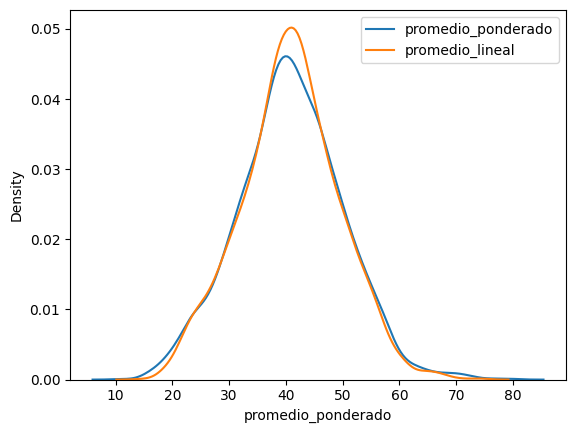

In [ ]:
sns.kdeplot(df_predicciones['promedio_ponderado'], label='promedio_ponderado')
sns.kdeplot(df_predicciones['promedio_lineal'], label='promedio_lineal')
plt.legend()
plt.show()

In [ ]:
df_predicciones.to_csv('predicciones.csv', index=False)
df_predicciones[['ID','promedio_ponderado']].rename(columns={'promedio_ponderado':'track_popularity'}).to_csv('promedio_3_modelos_razonables.csv', index=False)